# Gene annotation and duplicate resolution

**基因注释与重复条目处理**

Map Ensembl identifiers to symbols and inspect which expression rows survive. / 将 Ensembl ID 映射到基因符号，并检查保留情况。

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
counts = load("eset_stad")
annotation = load("anno_grch38")
input_shape = counts.shape
display(counts.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
rownames,,,,
ENSG00000000003,8006.0,2114.0,767.0,1556.0
ENSG00000000005,1.0,0.0,5.0,5.0
ENSG00000000419,3831.0,2600.0,1729.0,1760.0
ENSG00000000457,1126.0,745.0,1040.0,1260.0
ENSG00000000460,857.0,463.0,231.0,432.0


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.anno_eset(counts, annotation, symbol="symbol", probe="id", method="mean")
elapsed = perf_counter() - started
display(save_result(result, "01_gene_annotation", elapsed, input_shape))

Annotation DataFrame shape: (66533, 11)
Row number of original eset: 60483
Probes matched annotation: 60322 / 60483
99.73% of probes were annotated
Row number after filtering: 50181
Completed in 0.038 s; input 60,483 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,01_gene_annotation,0.038222,"[60483, 10]","{'result': [50181, 10]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380,TCGA-BR-8592,TCGA-BR-8686,TCGA-BR-A4IV,TCGA-BR-A4J4,TCGA-BR-A4J9,TCGA-FP-7916
symbol,,,,,,,,,,
MT-CO1,849866.000010,858644.000007,2.296926e+06,1.851900e+06,2.317798e+06,713602.999986,2.547162e+06,1.172210e+06,3.164451e+06,1.019632e+06
MT-ND4,439550.999999,477309.999990,1.671108e+06,1.061786e+06,1.573003e+06,568875.000009,1.633347e+06,1.860155e+06,1.773153e+06,5.016940e+05
MYH11,49089.999999,231643.999995,1.891538e+06,2.278901e+06,2.268508e+06,89832.000003,1.867340e+06,5.872000e+04,2.473820e+06,1.031430e+05
MT-RNR2,638863.000016,393661.999997,1.612115e+06,7.592550e+05,1.195967e+06,527914.000007,1.890956e+06,1.323163e+06,1.606934e+06,4.876830e+05
FLNA,78921.000000,291181.999991,1.255093e+06,1.469937e+06,1.586939e+06,105371.000004,1.483645e+06,1.296920e+05,1.622593e+06,1.907140e+05


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

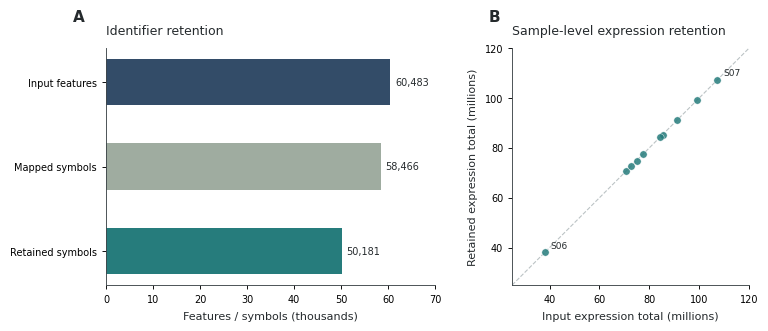

In [5]:
mapped = annotation.loc[annotation["id"].isin(counts.index) & annotation["symbol"].notna() & annotation["symbol"].ne("NA_NA")]
counts_summary = pd.Series({"Input features": len(counts), "Mapped symbols": mapped["symbol"].nunique(), "Retained symbols": len(result)})
fig, axes = plt.subplots(1, 2, figsize=(8.1, 3.2), gridspec_kw={"width_ratios": [1, 1.1]}, layout="constrained")
axes[0].barh(counts_summary.index[::-1], counts_summary.values[::-1] / 1000, color=[TEAL, "#9FACA0", NAVY], height=0.55)
axes[0].set(xlabel="Features / symbols (thousands)", xlim=(0, 70))
for y, value in enumerate(counts_summary.values[::-1]):
    axes[0].text(value / 1000 + 1, y, f"{value:,}", va="center", fontsize=7)
scatter(axes[1], counts.sum().to_numpy() / 1e6, result.sum().to_numpy() / 1e6,
        "Input expression total (millions)", "Retained expression total (millions)", annotate=True)
limits = (25, 120)
axes[1].plot(limits, limits, color="#BCC3C5", linestyle="--", linewidth=0.8, zorder=0)
axes[1].set(xlim=limits, ylim=limits)
axes[1].set_aspect("equal", adjustable="box")
panel(axes[0], "A", "Identifier retention")
panel(axes[1], "B", "Sample-level expression retention")
save_figure(fig, '01_gene_annotation')


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

`method='mean'` ranks duplicate candidates by their mean expression and retains the highest-scoring row. It does **not** average those rows into one. Rows that are all zero or all missing are removed according to IOBRpy. Raw sample totals can therefore change; annotation is not normalization.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/01_gene_annotation.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.